## 1. Importing libraries

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

## 2. Loading Data

In [74]:
df = pd.read_csv("../data/raw/spam.csv", encoding="latin-1")
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


## 3. Exploratory Data Analysis

In [75]:
print(f"Dataset shape: {df.shape}")
print(f"\nDataset column names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n {df.isnull().sum()}")
print(f"\nFirst 5 rows: \n{df.head()}")

Dataset shape: (5572, 5)

Dataset column names: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data types:
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object

Missing values:
 v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

First 5 rows: 
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [76]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [77]:
df = df.rename(columns={"v1": "label", "v2": "sms-text"})
print(f"\nDataset column names: {df.columns.tolist()}")
print(f"Dataset shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")


Dataset column names: ['label', 'sms-text']
Dataset shape: (5572, 2)

Data types:
label       object
sms-text    object
dtype: object


In [35]:
print("Class distribution:")
print(df["label"].value_counts())
print("\nClass distribution percentage:")
print(df["label"].value_counts(normalize=True) * 100)
print("\n")

Class distribution:
ham     4825
spam     747
Name: label, dtype: int64

Class distribution percentage:
ham     86.593683
spam    13.406317
Name: label, dtype: float64




In [78]:
print("Sample Spam SMS-Message:")
print(df[df["label"] == "spam"]["sms-text"].iloc[0])
print("\n")
print("Sample Ham SMS-Message:")
print(df[df["label"] == "ham"]["sms-text"].iloc[2])


Sample Spam SMS-Message:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


Sample Ham SMS-Message:
U dun say so early hor... U c already then say...


In [79]:
# Create length features 
df['char_count'] = df['sms-text'].str.len()
df['word_count'] = df['sms-text'].str.split().apply(len)

# Check stastistics by class
print(df.groupby('label').agg({'char_count': 'mean', 'word_count': 'mean'}))

       char_count  word_count
label                        
ham     71.023627   14.200622
spam   138.866131   23.851406


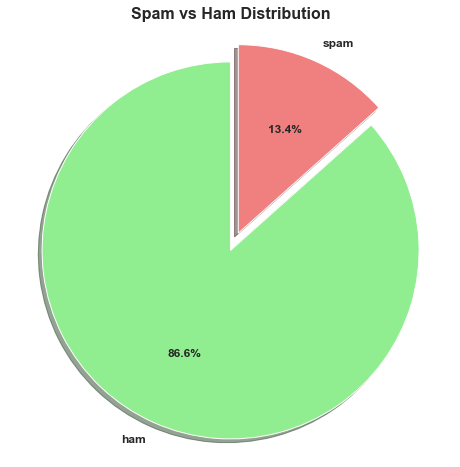

<Figure size 432x288 with 0 Axes>

In [80]:
# Get value counts
label_counts = df['label'].value_counts()

# Create pie chart
plt.figure(figsize=(8, 8))
colors = ['lightgreen', 'lightcoral']
explode = (0.05, 0.05)  # Slightly separate the slices

plt.pie(label_counts.values, 
        labels=label_counts.index, 
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Spam vs Ham Distribution', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures circular pie
plt.show()
plt.savefig('../results/plots/spam_vs_ham_class_distribution.png')

In [81]:
spam_count = (df['label'] == 'spam').sum()
ham_count = (df['label'] == 'ham').sum()

# Calculate imbalance ratio
imbalance_ratio = ham_count / spam_count
print("="*50)
print("CLASS IMBALANCE ANALYSIS")
print("="*50)
print(f"Ham messages: {ham_count}")
print(f"Spam messages: {spam_count}")
print(f"Total messages: {len(df)}")
print(f"\nImbalance Ratio (Ham:Spam): {imbalance_ratio:.2f}:1")
print(f"This means there are {imbalance_ratio:.2f} ham messages for every 1 spam message")
print(f"Models trained on imbalanced data may perform poorly on spam detection")
print("="*50)

CLASS IMBALANCE ANALYSIS
Ham messages: 4825
Spam messages: 747
Total messages: 5572

Imbalance Ratio (Ham:Spam): 6.46:1
This means there are 6.46 ham messages for every 1 spam message
Models trained on imbalanced data may perform poorly on spam detection


In [84]:
spam_messages = df[df['label'] == 'spam']['sms-text']
ham_messages = df[df['label'] == 'ham']['sms-text']

combined_spam_message = ' '.join(spam_messages).lower()
combined_ham_message = ' '.join(ham_messages).lower()

print(f"\nCombined Spam Message:\n{combined_spam_message}")
print(f"\nCombined Ham Message:\n{combined_ham_message}")

spam_words = combined_spam_message.split()
ham_words = combined_ham_message.split()

spam_word_counts = Counter(spam_words)
ham_word_counts = Counter(ham_words)

spam_df = pd.DataFrame({
    'word': spam_word_counts.keys(),
    'count': spam_word_counts.values()
})

ham_df = pd.DataFrame({
    'word': ham_word_counts.keys(),
    'count': ham_word_counts.values()
})

spam_df = spam_df.sort_values(by='count', ascending=False)
ham_df = ham_df.sort_values(by='count', ascending=False)

print(f"\nTop 20 Spam Words:\n{spam_df.head(20)}")
print(f"\nTop 20 Ham Words:\n{ham_df.head(20)}")


Combined Spam Message:
free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std txt rate)t&c's apply 08452810075over18's freemsg hey there darling it's been 3 week's now and no word back! i'd like some fun you up for it still? tb ok! xxx std chgs to send, å£1.50 to rcv winner!! as a valued network customer you have been selected to receivea å£900 prize reward! to claim call 09061701461. claim code kl341. valid 12 hours only. had your mobile 11 months or more? u r entitled to update to the latest colour mobiles with camera for free! call the mobile update co free on 08002986030 six chances to win cash! from 100 to 20,000 pounds txt> csh11 and send to 87575. cost 150p/day, 6days, 16+ tsandcs apply reply hl 4 info urgent! you have won a 1 week free membership in our å£100,000 prize jackpot! txt the word: claim to no: 81010 t&c www.dbuk.net lccltd pobox 4403ldnw1a7rw18 xxxmobilemovieclub: to use your credit, click the wap link in t

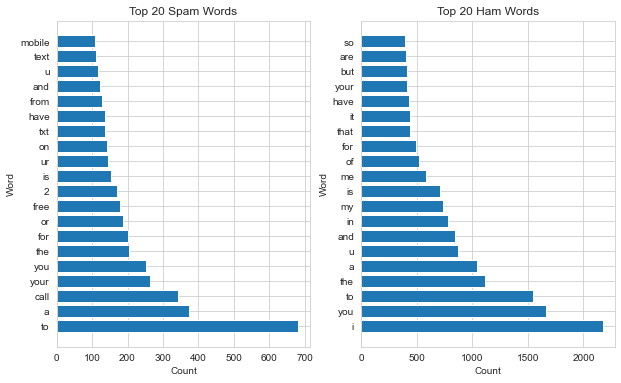

<Figure size 432x288 with 0 Axes>

In [91]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.barh(spam_df['word'][:20], spam_df['count'][:20])
plt.title('Top 20 Spam Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.subplot(1,2,2)
plt.barh(ham_df['word'][:20], ham_df['count'][:20:])
plt.title('Top 20 Ham Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()
plt.savefig('../results/plots/top_20_words.png')

We notice that the top words are not meaningful and they're mostly stop words. The only word that is meaningful is "free" in the spam messages but for now we really can't differentiate between spam and ham.

## 4. Preprocessing Data

## 5. Feature Engineering

## 6. Model Training

## 7. Model Evaluation

## 8. Model Export